# Retail Operations RAG - Maison Kurt

POC d'assistant IA pour retrouver rapidement une procédure dans une documentation retail. Maison Kurt et sa documentation sont fictives, aucune valeur contractuelle.

**Corpus** (`data/`, 4 guides) : cas particuliers, commandes en ligne, remboursements, retours et échanges.

**Cible** : un conseiller de vente ou un membre du service client qui doit retrouver la procédure applicable à une situation, sans avoir à ouvrir plusieurs documents.

**Jeu de questions** : `questions.json` contient 15 questions avec les mots-clés attendus, utilisées pour évaluer le retrieval et la génération.

**Pipeline** : documents → chunks → embeddings → index FAISS → retrieval → contexte → génération → évaluation.

**Modèles** :
- Embeddings : `intfloat/multilingual-e5-small` (local, CPU)
- Base vectorielle : FAISS
- LLM : `llama3.2` via Ollama (alternative : OpenAI, via `LLM_PROVIDER`)

Le notebook vérifie séparément : le retrieval (hit-rate), la génération (contexte réellement transmis, réponse produite), la fidélité et l'exactitude (LLM-as-a-judge), et le garde-fou sur des questions hors périmètre.

> Limite : le hit-rate est une approximation par mots-clés, pas un Recall@k annoté. Le jeu de questions sert à illustrer la méthode d'évaluation, pas à mesurer une performance de production.

## 1. Installation / Imports

In [1]:
# À exécuter uniquement si nécessaire :
%pip install -r requirements.txt
%pip install ipykernel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\jboul\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\jboul\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import sys
import os

# Configuration du LLM choisi pour ce projet
os.environ["LLM_PROVIDER"] = "ollama"
os.environ["OLLAMA_MODEL"] = "llama3.2"

HERE = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        p for p in (HERE, HERE.parent)
        if (
            (p / "questions.json").exists()
            and (p / "data").is_dir()
        )
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Impossible de trouver la racine du projet. "
        "Ouvre VS Code sur le dossier retail-operations-rag."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ROOT = PROJECT_ROOT
DATA_DIR = ROOT / "data"
QUESTIONS = ROOT / "questions.json"

print("Racine du projet :", ROOT)
print("Dossier data     :", DATA_DIR)
print("questions.json   :", QUESTIONS.exists())
print("requirements.txt :", (ROOT / "requirements.txt").exists())
print("Documents .md    :", len(list(DATA_DIR.glob("*.md"))))

print("\nLLM provider     :", os.environ["LLM_PROVIDER"])
print("LLM model        :", os.environ["OLLAMA_MODEL"])

Racine du projet : C:\Users\jboul\Desktop\Dev\Linkdin\demo\retail-operations-rag
Dossier data     : C:\Users\jboul\Desktop\Dev\Linkdin\demo\retail-operations-rag\data
questions.json   : True
requirements.txt : True
Documents .md    : 4

LLM provider     : ollama
LLM model        : llama3.2


## 2. Chargement du corpus / documents


In [3]:
from langchain_core.documents import Document

documents = []

for path in sorted(DATA_DIR.glob("*.md")):
    text = path.read_text(encoding="utf-8")

    documents.append(
        Document(
            page_content=text,
            metadata={"source": path.name}
        )
    )

print("Nombre de documents :", len(documents))

for doc in documents:
    print("-", doc.metadata["source"])

Nombre de documents : 4
- guide_cas_particuliers.md
- guide_commandes_en_ligne.md
- guide_remboursements.md
- guide_retours_echanges.md


## 3. Pipeline retrieval / génération

On sépare volontairement le retrieval et la génération, définis directement dans les cellules ci-dessous. Ça permet d'évaluer le retriever sans dépendre du LLM, puis d'envoyer explicitement le contexte récupéré au générateur.

## 4. Chunking

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Paramètres du chunking
CHUNK_SIZE = 400
CHUNK_OVERLAP = 50

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP
)

chunks = splitter.split_documents(documents)

print(" PARAMÈTRES DU CHUNKING")
print("=" * 60)
print("Nombre de chunks :", len(chunks))
print("Chunk size       :", CHUNK_SIZE, "caractères")
print("Chunk overlap    :", CHUNK_OVERLAP, "caractères")

# Affichage des premiers chunks
for i, chunk in enumerate(chunks[:5], 1):
    print("\n" + "=" * 70)
    print(f"CHUNK {i} : {len(chunk.page_content)} caractères")
    print("=" * 70)
    print(chunk.page_content)
    print("Source :", chunk.metadata["source"])

 PARAMÈTRES DU CHUNKING
Nombre de chunks : 27
Chunk size       : 400 caractères
Chunk overlap    : 50 caractères

CHUNK 1 — 306 caractères
# Maison Kurt — Guide opérationnel des cas particuliers

Version : 1.0  
Document fictif — usage interne

## 1. Produits de beauté et cosmétiques

Un produit cosmétique ou de beauté ouvert ne peut pas être traité comme un retour standard lorsque son ouverture ne permet plus de garantir son état d'origine.
Source : guide_cas_particuliers.md

CHUNK 2 — 276 caractères
Le conseiller doit vérifier l'état du produit et les conditions applicables à la catégorie avant de valider le retour.

Un produit de beauté non ouvert et dans son état d'origine peut être traité selon les conditions standard applicables.

## 2. Bijoux et accessoires précieux
Source : guide_cas_particuliers.md

CHUNK 3 — 347 caractères
## 2. Bijoux et accessoires précieux

Pour les bijoux et accessoires précieux, la preuve d'achat et l'état d'origine doivent être vérifiés avec une attenti

In [5]:
lengths = [len(chunk.page_content) for chunk in chunks]

print("Nombre total de chunks :", len(chunks))
print("Chunk le plus court    :", min(lengths), "caractères")
print("Chunk le plus long     :", max(lengths), "caractères")
print("Longueur moyenne       :", round(sum(lengths) / len(lengths)), "caractères")

Nombre total de chunks : 27
Chunk le plus court    : 154 caractères
Chunk le plus long     : 400 caractères
Longueur moyenne       : 328 caractères


**Observations.** 27 chunks, entre 154 et 400 caractères, 328 en moyenne, cohérent avec le `chunk_size` de 400 caractères configuré.

## 5. Embeddings

In [6]:
from langchain_huggingface import HuggingFaceEmbeddings

EMBED_MODEL = "intfloat/multilingual-e5-small"

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL
)

print(" MODÈLE D'EMBEDDINGS")
print("=" * 60)
print("Modèle chargé :", EMBED_MODEL)

# Test
test_text = chunks[0].page_content
test_vector = embedding_model.embed_query(test_text)

print("Texte encodé :", len(test_text), "caractères")
print("Vecteur généré :", len(test_vector), "dimensions")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

 MODÈLE D'EMBEDDINGS
Modèle chargé : intfloat/multilingual-e5-small


Texte encodé : 306 caractères
Vecteur généré : 384 dimensions


**Configuration retenue**

| Élément          | Choix                     |
| ---------------- | ------------------------- |
| Chunk size       | **400**                   |
| Chunk overlap    | **50**                    |
| Embedding        | **multilingual-e5-small** |
| Dimensions       | **384**                   |
| Nombre de chunks | **27**                    |

## 6. FAISS

In [7]:
from langchain_community.vectorstores import FAISS

store = FAISS.from_documents(
    chunks,
    embedding_model
)

print("INDEX FAISS")
print("=" * 60)
print("Nombre de chunks :", len(chunks))
print("Nombre de vecteurs dans FAISS :", store.index.ntotal)

for i, doc in enumerate(chunks, 1):
    print(f"\n--- CHUNK {i} ---")
    print(f"Source : {doc.metadata.get('source', 'inconnue')}")
    print(doc.page_content[:500])
    print()

C:\Users\jboul\AppData\Local\Temp\ipykernel_19552\3784442057.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


INDEX FAISS
Nombre de chunks : 27
Nombre de vecteurs dans FAISS : 27

--- CHUNK 1 ---
Source : guide_cas_particuliers.md
# Maison Kurt — Guide opérationnel des cas particuliers

Version : 1.0  
Document fictif — usage interne

## 1. Produits de beauté et cosmétiques

Un produit cosmétique ou de beauté ouvert ne peut pas être traité comme un retour standard lorsque son ouverture ne permet plus de garantir son état d'origine.


--- CHUNK 2 ---
Source : guide_cas_particuliers.md
Le conseiller doit vérifier l'état du produit et les conditions applicables à la catégorie avant de valider le retour.

Un produit de beauté non ouvert et dans son état d'origine peut être traité selon les conditions standard applicables.

## 2. Bijoux et accessoires précieux


--- CHUNK 3 ---
Source : guide_cas_particuliers.md
## 2. Bijoux et accessoires précieux

Pour les bijoux et accessoires précieux, la preuve d'achat et l'état d'origine doivent être vérifiés avec une attention particulière.

En cas de doute 

**Observations :** 27 chunks et 27 vecteurs dans FAISS

## 7. Retrieval - Recherche des passages pertinents

Le **retriever** cherche les chunks les plus proches de la question dans l'espace vectoriel.

`k=4` signifie que l'on récupère les **4 passages les plus pertinents**.

### Test

Un **hit** signifie ici que les mots-clés attendus pour la question sont présents dans les passages récupérés.

In [8]:
retriever = store.as_retriever(
    search_kwargs={"k": 4}
)

question = "Quel est le délai de retour d'un article ?"

sources = retriever.invoke(question)

print(" RETRIEVAL")
print("=" * 70)
print("Question :", question)
print("Nombre de sources récupérées :", len(sources))

for i, source in enumerate(sources, 1):
    print("\n" + "=" * 70)
    print(f"SOURCE {i}")
    print("=" * 70)
    print(source.page_content)
    print("Source :", source.metadata["source"])

 RETRIEVAL
Question : Quel est le délai de retour d'un article ?
Nombre de sources récupérées : 4

SOURCE 1
Si le nouvel article est plus cher, le client règle la différence. S'il est moins cher, la différence est remboursée selon la procédure de remboursement.

## 3. Articles soldés

Les articles soldés restent éligibles au retour et à l'échange, sauf mention contraire indiquée au moment de l'achat.

Pour les articles soldés, le délai de retour est de 14 jours calendaires.
Source : guide_retours_echanges.md

SOURCE 2
## 2. Échange d'un article standard

Un échange peut être demandé dans un délai de 30 jours calendaires.

L'article doit être dans son état d'origine et la preuve d'achat doit être disponible.

L'échange est effectué sous réserve de disponibilité du nouvel article.
Source : guide_retours_echanges.md

SOURCE 3
# Maison Kurt — Guide opérationnel des retours et échanges

Version : 1.0  
Document fictif — usage interne

## 1. Retour d'un article standard

Un article standard 

**Observations.** Pour cette question, FAISS renvoie 4 passages : le délai des articles soldés (14 jours), l'échange standard (30 jours), le retour standard (30 jours, c'est le passage attendu), et le cas de dépassement de délai / article défectueux. L'information correcte est bien récupérée, mais elle n'arrive pas en première position.

In [9]:
retriever = store.as_retriever(
    search_kwargs={"k": 4}
)

question = "Les articles soldés peuvent-ils être retournés ?"

sources = retriever.invoke(question)

print(" RETRIEVAL")
print("=" * 70)
print("Question :", question)
print("Nombre de sources récupérées :", len(sources))

for i, source in enumerate(sources, 1):
    print("\n" + "=" * 70)
    print(f"SOURCE {i}")
    print("=" * 70)
    print(source.page_content)
    print("Source :", source.metadata["source"])

 RETRIEVAL
Question : Les articles soldés peuvent-ils être retournés ?
Nombre de sources récupérées : 4

SOURCE 1
Si le nouvel article est plus cher, le client règle la différence. S'il est moins cher, la différence est remboursée selon la procédure de remboursement.

## 3. Articles soldés

Les articles soldés restent éligibles au retour et à l'échange, sauf mention contraire indiquée au moment de l'achat.

Pour les articles soldés, le délai de retour est de 14 jours calendaires.
Source : guide_retours_echanges.md

SOURCE 2
## 3. Article personnalisé défectueux

Un article personnalisé ne peut normalement pas être retourné ou échangé.

Toutefois, lorsqu'un défaut est constaté, le conseiller doit ouvrir un dossier de prise en charge et transmettre le dossier au responsable de rayon.

## 4. Client VIP

Le statut VIP ne modifie pas automatiquement les règles de retour.
Source : guide_cas_particuliers.md

SOURCE 3
La preuve d'achat et l'état d'origine du produit restent requis.

## 4. Arti

In [10]:
import json

items = json.loads(
    QUESTIONS.read_text(encoding="utf-8")
)

retriever = store.as_retriever(
    search_kwargs={"k": 4}
)

print("Nombre de questions d'évaluation :", len(items))

Nombre de questions d'évaluation : 15


In [11]:
def retrieval_hit(sources, mots_cles_attendus):
    """
    Vérifie si au moins un des mots-clés attendus
    apparaît dans les passages récupérés.
    """

    if not mots_cles_attendus:
        return None

    texte = " ".join(
        source.page_content.lower()
        for source in sources
    )

    return all(
        mot.lower() in texte
        for mot in mots_cles_attendus
    )


def retrieval_results(k):

    retriever_k = store.as_retriever(
        search_kwargs={"k": k}
    )

    rows = []
    hits = 0
    in_scope = 0

    for item in items:

        question = item["question"]

        sources = retriever_k.invoke(question)

        hit = retrieval_hit(
            sources,
            item.get("mots_cles_attendus", [])
        )

        if hit is not None:
            in_scope += 1
            hits += int(hit)

        rows.append({
            "question": question,
            "hit": hit,
            "n_sources": len(sources)
        })

    return hits, in_scope, rows

### Inspection question par question

Cette cellule permet de voir précisément quelles questions produisent un **hit** et lesquelles échouent.

In [12]:
K = 4

_, _, rows = retrieval_results(k=K)

for row in rows:
    print("Question :", row["question"])
    print("Hit      :", row["hit"])
    print("Sources  :", row["n_sources"])
    print()

Question : Quel est le délai de retour d'un article standard acheté en magasin ?
Hit      : True
Sources  : 4

Question : Quelles sont les conditions pour accepter le retour d'un article standard ?
Hit      : True
Sources  : 4

Question : Quel est le délai de retour pour un article soldé ?
Hit      : True
Sources  : 4

Question : Un article personnalisé peut-il être retourné ?
Hit      : True
Sources  : 4

Question : Que faire si le client n'a pas sa preuve d'achat ?
Hit      : True
Sources  : 4

Question : Comment est remboursé un achat payé par carte bancaire ?
Hit      : True
Sources  : 4

Question : Que se passe-t-il lorsqu'un article échangé est plus cher ?
Hit      : True
Sources  : 4

Question : Quelle information faut-il rechercher en priorité pour une commande en ligne ?
Hit      : True
Sources  : 4

Question : Que doit faire un conseiller face à un colis reçu endommagé ?
Hit      : True
Sources  : 4

Question : Un client VIP bénéficie-t-il automatiquement de règles de retour 

### Évaluation du retrieval - Hit Rate

Le **retrieval hit-rate** mesure la capacité du moteur de recherche à récupérer l'information attendue.

**Hit Rate = hits / questions évaluables**

Cette mesure évalue le **retriever**, pas le LLM.

📊 RETRIEVAL HIT RATE
k=1 | hits=10 | questions=12 | hit rate=83.3%
k=2 | hits=12 | questions=12 | hit rate=100.0%
k=3 | hits=12 | questions=12 | hit rate=100.0%
k=4 | hits=12 | questions=12 | hit rate=100.0%
k=5 | hits=12 | questions=12 | hit rate=100.0%


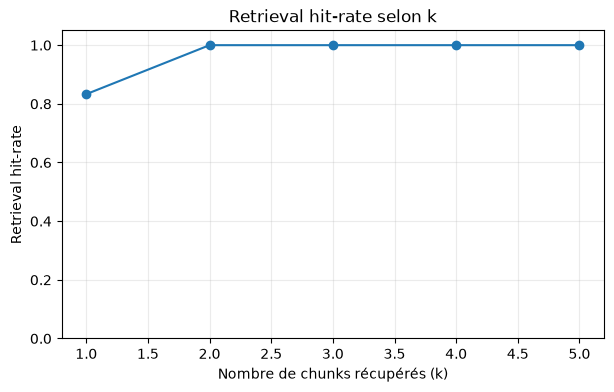

In [13]:
import matplotlib.pyplot as plt

retrieval_summary = []

for k in (1, 2, 3, 4, 5):

    hits, in_scope, rows = retrieval_results(k)

    rate = hits / max(in_scope, 1)

    retrieval_summary.append({
        "k": k,
        "hits": hits,
        "in_scope": in_scope,
        "hit_rate": round(rate, 3)
    })


print("📊 RETRIEVAL HIT RATE")
print("=" * 60)

for result in retrieval_summary:
    print(
        f"k={result['k']} | "
        f"hits={result['hits']} | "
        f"questions={result['in_scope']} | "
        f"hit rate={result['hit_rate']:.1%}"
    )

ks = [r["k"] for r in retrieval_summary]
rates = [r["hit_rate"] for r in retrieval_summary]

plt.figure(figsize=(7, 4))
plt.plot(ks, rates, marker="o")
plt.xlabel("Nombre de chunks récupérés (k)")
plt.ylabel("Retrieval hit-rate")
plt.title("Retrieval hit-rate selon k")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.25)
plt.show()

### Choix de k

Le benchmark du retrieval montre qu'un k=2 permet d'obtenir un Hit Rate de 100 % sur les 12 questions évaluables, contre 83,3 % avec k=1. Au-delà de deux passages, aucune amélioration supplémentaire n'est observée. Le paramètre k=2 a donc été retenu afin de limiter la quantité de contexte transmise au LLM tout en conservant une couverture complète des informations attendues.

In [14]:
K = 2
retriever = store.as_retriever(search_kwargs={"k": K})

print(f"✅ k retenu pour la génération : {K}")

✅ k retenu pour la génération : 2


## 8. Construction de la chaîne de génération

Ici, on ne met volontairement **pas le retriever dans la chaîne de génération**.

Le notebook réalise explicitement :

`question → retriever → sources → context`

puis :

`context + question → prompt → Llama 3.2 → réponse`

Cette séparation évite l'erreur où un dictionnaire `{context, question}` serait envoyé par inadvertance au retriever.

In [15]:
from langchain_ollama import ChatOllama

def get_llm(temperature=0.0):
    return ChatOllama(
        model=os.getenv("OLLAMA_MODEL", "llama3.2"),
        temperature=temperature
    )

print(" Fonction get_llm prête.")
print("LLM :", os.getenv("OLLAMA_MODEL", "llama3.2"))

 Fonction get_llm prête.
LLM : llama3.2


In [16]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# K retenu après l'évaluation du retrieval
K = 2

retriever = store.as_retriever(
    search_kwargs={"k": K}
)

PROMPT = (
    "Tu es un assistant d'analyse de documents opérationnels retail.\n\n"

    "Réponds à la question UNIQUEMENT à partir du contexte fourni.\n\n"

    "IMPORTANT :\n"
    "- Lis attentivement toutes les informations pertinentes du contexte.\n"
    "- Si le contexte indique qu'une règle ne s'applique PAS, "
    "réponds clairement que la règle ne s'applique pas.\n"
    "- Les formulations négatives comme « ne modifie pas », "
    "« ne signifie pas automatiquement » ou « ne peut pas » "
    "contiennent des informations importantes et doivent être utilisées "
    "pour répondre à la question.\n"
    "- Ne réponds jamais « Information non trouvée » si le contexte "
    "contient explicitement ou directement la réponse.\n\n"

    "Si aucune information permettant de répondre à la question "
    "n'est présente dans le contexte, réponds EXACTEMENT : "
    "« Information non trouvée dans les documents. »\n\n"

    "Sois concis et factuel.\n"
    "Lorsque tu utilises une information du contexte, cite entre "
    "guillemets l'extrait correspondant.\n\n"

    "Contexte :\n{context}\n\n"
    "Question : {question}\n"
    "Réponse :"
)

generation_chain = (
    ChatPromptTemplate.from_template(PROMPT)
    | get_llm(temperature=0.0)
    | StrOutputParser()
)

print("✅ Chaîne de génération prête.")
print("K :", K)
print("LLM :", os.getenv("OLLAMA_MODEL", "llama3.2"))

✅ Chaîne de génération prête.
K : 2
LLM : llama3.2


## Test de génération avec traçabilité des sources

On récupère d'abord les sources, puis on transmet **exactement ces sources** au LLM.

In [17]:
question = "Quel est le délai de retour d'un article ?"

# 1. Récupération des passages pertinents
sources = retriever.invoke(question)

# 2. Construction du contexte
context = "\n\n".join(
    source.page_content
    for source in sources
)

# 3. Génération de la réponse
answer = generation_chain.invoke({
    "context": context,
    "question": question
})

print("QUESTION")
print(question)

print("\n" + "=" * 70)
print("SOURCES RÉCUPÉRÉES")
print("=" * 70)

for i, source in enumerate(sources, 1):
    print(f"\n--- SOURCE {i} ---")
    print(source.page_content)
    print("Source :", source.metadata.get("source"))

print("\n" + "=" * 70)
print("RÉPONSE DU LLM")
print("=" * 70)
print(answer)

QUESTION
Quel est le délai de retour d'un article ?

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
Si le nouvel article est plus cher, le client règle la différence. S'il est moins cher, la différence est remboursée selon la procédure de remboursement.

## 3. Articles soldés

Les articles soldés restent éligibles au retour et à l'échange, sauf mention contraire indiquée au moment de l'achat.

Pour les articles soldés, le délai de retour est de 14 jours calendaires.
Source : guide_retours_echanges.md

--- SOURCE 2 ---
## 2. Échange d'un article standard

Un échange peut être demandé dans un délai de 30 jours calendaires.

L'article doit être dans son état d'origine et la preuve d'achat doit être disponible.

L'échange est effectué sous réserve de disponibilité du nouvel article.
Source : guide_retours_echanges.md

RÉPONSE DU LLM
Le délai de retour d'un article est de 14 jours calendaires.


**Observation.** Avec k=2, les deux passages récupérés parlent des articles soldés (14 jours) et de l'échange standard (30 jours). Le passage sur le retour standard (30 jours), qui répond directement à la question, n'est pas dans le contexte. Le LLM répond donc « 14 jours », en se basant sur le passage le plus proche mais pas le bon.

Ça montre que le hit-rate (présence des mots-clés dans le contexte récupéré) et la justesse de la réponse générée sont deux mesures différentes : elles peuvent diverger.

## Test avec plusieurs questions

On teste plusieurs questions représentatives des opérations retail pour voir si l'erreur revient.

In [44]:
def generate_answer(question):
    # Récupération des chunks pertinents
    sources = retriever.invoke(question)

    # Construction du contexte
    context = "\n\n".join(
        source.page_content
        for source in sources
    )

    # Génération avec Llama 3.2
    answer = generation_chain.invoke({
        "context": context,
        "question": question
    })

    return answer, sources

In [46]:
test_questions = [
    "Quel est le délai de retour pour un article soldé ?",
    "Comment est remboursé un achat payé par carte bancaire ?",
    "Que doit faire un conseiller face à un colis reçu endommagé ?",
    "Une commande Marketplace peut-elle être retournée en magasin ?",
]

for question in test_questions:

    answer, sources = generate_answer(question)

    print("\n" + "=" * 70)
    print("QUESTION")
    print(question)

    print("\nRÉPONSE DU LLM")
    print(answer)

    print("\nSOURCES RÉCUPÉRÉES")
    for i, source in enumerate(sources, 1):
        print(f"\n--- SOURCE {i} ---")
        print(source.page_content)
        print("Source :", source.metadata.get("source"))


QUESTION
Quel est le délai de retour pour un article soldé ?

RÉPONSE DU LLM
Le délai de retour pour un article soldé est de 14 jours calendaires.

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
Si le nouvel article est plus cher, le client règle la différence. S'il est moins cher, la différence est remboursée selon la procédure de remboursement.

## 3. Articles soldés

Les articles soldés restent éligibles au retour et à l'échange, sauf mention contraire indiquée au moment de l'achat.

Pour les articles soldés, le délai de retour est de 14 jours calendaires.
Source : guide_retours_echanges.md

--- SOURCE 2 ---
## 2. Échange d'un article standard

Un échange peut être demandé dans un délai de 30 jours calendaires.

L'article doit être dans son état d'origine et la preuve d'achat doit être disponible.

L'échange est effectué sous réserve de disponibilité du nouvel article.
Source : guide_retours_echanges.md

QUESTION
Comment est remboursé un achat payé par carte bancaire ?

RÉPONSE DU LLM
"Le re

**Résultats des 4 tests**

| Question | Résultat |
| --- | --- |
| Article soldé | correct |
| Remboursement carte bancaire | correct |
| Colis endommagé | correct |
| Retour Marketplace en magasin | correct (information absente signalée) |

Le pipeline fonctionne comme attendu : question → embeddings → FAISS → 2 chunks → contexte → Llama 3.2 → réponse. Sur le dernier cas, le LLM ne cherche pas à inventer une règle et indique que l'information n'est pas dans les documents.

Sur les 3 premiers cas, le retriever ramène directement le bon passage. Sur le 4ème, il ramène deux passages distincts (Marketplace et retour en magasin) sans lien explicite entre eux, et le LLM comprend correctement qu'aucune règle ne les relie.

k=2 reste retenu pour la suite : le hit-rate est à 100 % et la génération fonctionne correctement sur ces exemples.

### Test du garde-fou

Une application RAG opérationnelle doit savoir refuser de répondre lorsque la documentation ne contient pas l'information.

On teste volontairement des questions hors périmètre.

In [53]:
guardrail_questions = [
    "Quelle est la politique de livraison internationale de Maison Kurt ?",
    "Quels sont les horaires d'ouverture des magasins Maison Kurt ?",
    "Comment contacter le service client par téléphone ?",
    "Quels moyens de paiement sont acceptés en magasin ?",
]

for question in guardrail_questions:

    sources = retriever.invoke(question)

    context = "\n\n".join(
        doc.page_content for doc in sources
    )

    response = generation_chain.invoke({
        "context": context,
        "question": question
    })

    print("=" * 70)
    print("QUESTION")
    print(question)

    print("\nRÉPONSE DU LLM")
    print(response)

    print("\nSOURCES RÉCUPÉRÉES")
    for i, source in enumerate(sources, 1):
        print(f"\n--- SOURCE {i} ---")
        print(source.page_content)

QUESTION
Quelle est la politique de livraison internationale de Maison Kurt ?

RÉPONSE DU LLM
Information non trouvée dans les documents.

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
# Maison Kurt — Guide opérationnel des retours et échanges

Version : 1.0  
Document fictif — usage interne

## 1. Retour d'un article standard

Un article standard acheté en magasin peut être retourné dans un délai de 30 jours calendaires à compter de la date d'achat.

--- SOURCE 2 ---
Les règles spécifiques du vendeur peuvent différer des règles applicables aux articles vendus directement par Maison Kurt.

En cas de doute, le dossier doit être orienté vers le support Marketplace.

## 6. Article acheté avec une promotion

Lorsqu'un article a bénéficié d'une promotion, le conseiller doit vérifier les conditions de l'offre avant de déterminer la modalité de remboursement.
QUESTION
Quels sont les horaires d'ouverture des magasins Maison Kurt ?

RÉPONSE DU LLM
Information non trouvée dans les documents.

SOURCES RÉC

**Bilan du garde-fou**

| Question | Résultat |
| --- | --- |
| Livraison internationale | information non trouvée (correct) |
| Horaires des magasins | information non trouvée (correct) |
| Téléphone du service client | information non trouvée (correct) |
| Moyens de paiement acceptés | réponse inventée à partir d'un passage sur les preuves d'achat (incorrect) |

Le garde-fou fonctionne dans 3 cas sur 4. Sur le dernier, la présence d'un contexte récupéré ne suffit pas à empêcher le LLM d'halluciner ou de mal interpréter un passage proche mais hors sujet.

## 9. Évaluation de la chaîne RAG complète

In [52]:


def answer_question(question):
    # 1. Retrieval
    sources = retriever.invoke(question)

    # 2. Construction du contexte
    context = "\n\n".join(
        source.page_content for source in sources
    )

    # 3. Génération
    answer = generation_chain.invoke({
        "context": context,
        "question": question
    })

    return answer, sources


print(" ÉVALUATION DE LA CHAÎNE RAG")
print("=" * 70)

for item in items:
    question = item["question"]

    answer, sources = answer_question(question)

    print("\n" + "=" * 70)
    print("QUESTION")
    print(question)

    print("\nRÉPONSE DU LLM")
    print(answer)

    print("\nSOURCES UTILISÉES")
    for i, source in enumerate(sources, 1):
        print(f"\n--- SOURCE {i} ---")
        print(source.page_content)
        print("Source :", source.metadata.get("source", "inconnue"))

 ÉVALUATION DE LA CHAÎNE RAG

QUESTION
Quel est le délai de retour d'un article standard acheté en magasin ?

RÉPONSE DU LLM
Selon le guide opérationnel des retours et échanges de la maison Kurt, le délai de retour d'un article standard acheté en magasin est de 30 jours calendaires à compter de la date d'achat.

SOURCES UTILISÉES

--- SOURCE 1 ---
# Maison Kurt — Guide opérationnel des retours et échanges

Version : 1.0  
Document fictif — usage interne

## 1. Retour d'un article standard

Un article standard acheté en magasin peut être retourné dans un délai de 30 jours calendaires à compter de la date d'achat.
Source : guide_retours_echanges.md

--- SOURCE 2 ---
## 2. Échange d'un article standard

Un échange peut être demandé dans un délai de 30 jours calendaires.

L'article doit être dans son état d'origine et la preuve d'achat doit être disponible.

L'échange est effectué sous réserve de disponibilité du nouvel article.
Source : guide_retours_echanges.md

QUESTION
Quelles sont les

**Deux cas à noter avant l'évaluation finale.**

Pour la question sur le statut VIP, le LLM répond correctement sur le fond (« le statut VIP ne modifie pas automatiquement les règles de retour ») mais ajoute une phrase sur le moyen de paiement, tirée d'un second passage récupéré qui ne concerne pas le statut VIP. Le retriever a bien ramené le bon passage en source 1, mais le passage secondaire (du bruit) se retrouve mélangé dans la réponse.

Même constat sur la question des articles en promotion : la réponse est correcte, mais cite un passage sur les articles personnalisés qui n'a rien à voir avec la question.

Ça illustre l'intérêt de séparer retrieval, génération et évaluation : le hit-rate était à 100 % avec k=2, mais ça ne garantit pas que le LLM utilise correctement chacun des passages fournis.

## 10. LLM-as-a-Judge

Un second LLM évalue chaque réponse du RAG selon deux critères, sur une échelle de 0 à 2 :

- **fidélité** : les affirmations de la réponse sont-elles soutenues par le contexte ?
- **exactitude** : la réponse répond-elle correctement à la question ?

Le juge reçoit la question, les mêmes sources que celles transmises au générateur, et la réponse produite par le RAG.

In [62]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

judge_llm = ChatOllama(
    model=os.getenv("OLLAMA_MODEL", "llama3.2"),
    temperature=0.0
)

JUDGE_PROMPT = """
Tu es un évaluateur strict d'un système RAG.

Évalue la réponse uniquement à partir du contexte fourni.

Question :
{question}

Contexte :
{context}

Réponse du RAG :
{answer}

Évalue deux critères :

1. FIDÉLITÉ
0 = la réponse contient des informations inventées ou contredites par le contexte
1 = la réponse contient des informations partiellement soutenues, hors sujet ou insuffisamment justifiées
2 = toutes les affirmations importantes sont soutenues par le contexte

2. EXACTITUDE
0 = la réponse est incorrecte ou contredit le contexte
1 = la réponse est partiellement correcte
2 = la réponse répond correctement à la question selon le contexte

IMPORTANT POUR LES QUESTIONS HORS PÉRIMÈTRE :
Si la question demande une information qui n'est pas présente dans le contexte et que le RAG répond exactement :
"Information non trouvée dans les documents."
alors cette réponse est considérée comme correcte.

Dans ce cas :
FIDÉLITÉ = 2
EXACTITUDE = 2

Une réponse hors périmètre qui invente une information doit en revanche recevoir :
FIDÉLITÉ = 0
EXACTITUDE = 0

Une information vraie mais hors sujet peut diminuer la fidélité, mais ne doit pas automatiquement diminuer l'exactitude si la réponse principale est correcte.

Réponds STRICTEMENT dans ce format :

FIDELITE: 0, 1 ou 2
EXACTITUDE: 0, 1 ou 2
COMMENTAIRE: une phrase courte.
"""

judge_chain = (
    ChatPromptTemplate.from_template(JUDGE_PROMPT)
    | judge_llm
    | StrOutputParser()
)

print("✅ LLM-as-a-Judge prêt.")

✅ LLM-as-a-Judge prêt.


In [63]:
judge_results = []

for item in items:

    question = item["question"]

    # 1. Retrieval
    sources = retriever.invoke(question)

    # 2. Construction du contexte
    context = "\n\n".join(
        source.page_content for source in sources
    )

    # 3. Génération de la réponse
    answer = generation_chain.invoke({
        "context": context,
        "question": question
    })

    # 4. Évaluation par le juge
    evaluation = judge_chain.invoke({
        "question": question,
        "answer": answer,
        "context": context
    })

    judge_results.append({
        "question": question,
        "answer": answer,
        "evaluation": evaluation
    })

    print("\n" + "=" * 70)
    print("QUESTION")
    print(question)

    print("\nRÉPONSE DU RAG")
    print(answer)

    print("\nJUGEMENT")
    print(evaluation)


QUESTION
Quel est le délai de retour d'un article standard acheté en magasin ?

RÉPONSE DU RAG
Selon le guide opérationnel des retours et échanges de la maison Kurt, le délai de retour d'un article standard acheté en magasin est de 30 jours calendaires à compter de la date d'achat.

JUGEMENT
FIDÉLITÉ: 2
EXACTITUDE: 2
COMMENTAIRE: La réponse est exactement conforme au contexte fourni, sans aucune information inventée ou hors sujet.

QUESTION
Quelles sont les conditions pour accepter le retour d'un article standard ?

RÉPONSE DU RAG
Selon le contexte, les conditions pour accepter le retour d'un article standard sont les suivantes :

* L'article doit être dans son état d'origine.
* L'article doit être non porté, non utilisé.
* L'article doit être accompagné de ses étiquettes lorsqu'elles étaient présentes lors de l'achat.
* La preuve d'achat doit être présentée, ce qui peut être un ticket de caisse, une facture ou une preuve d'achat numérique.
* Le retour doit être conforme.

JUGEMENT
FI

**Limite du juge.** Sur ce jeu de test, le juge n'''est pas toujours cohérent : pour les deux dernières questions hors périmètre, il attribue 0/0 alors que sa propre justification dit explicitement que la réponse « Information non trouvée dans les documents » est correcte. Les scores globaux ci-dessous sont donc à lire comme indicatifs, pas comme une mesure fiable de la qualité du RAG.

### Synthèse des scores du juge

Les scores sont descriptifs pour ce petit jeu de test. Ils ne constituent pas une validation statistique d'un système de production.

In [68]:
import re
from statistics import mean

fidelite_scores = []
exactitude_scores = []

for row in judge_results:
    evaluation = row["evaluation"]

    fidelite = re.search(r"FID[ÉE]LIT[ÉE]\s*:\s*(\d+)", evaluation, re.IGNORECASE)
    exactitude = re.search(r"EXACTITUDE\s*:\s*(\d+)", evaluation, re.IGNORECASE)

    if fidelite:
        fidelite_scores.append(int(fidelite.group(1)))

    if exactitude:
        exactitude_scores.append(int(exactitude.group(1)))

print("=" * 70)
print("RÉSULTATS GLOBAUX (LLM-AS-A-JUDGE)")
print("=" * 70)

print("Nombre de questions :", len(judge_results))
print("Scores de fidélité récupérés :", len(fidelite_scores))
print("Scores d'exactitude récupérés :", len(exactitude_scores))

if fidelite_scores:
    print(f"\nFidélité moyenne   : {mean(fidelite_scores):.2f} / 2")

if exactitude_scores:
    print(f"Exactitude moyenne : {mean(exactitude_scores):.2f} / 2")

RÉSULTATS GLOBAUX — LLM-AS-A-JUDGE
Nombre de questions : 15
Scores de fidélité récupérés : 15
Scores d'exactitude récupérés : 15

Fidélité moyenne   : 1.73 / 2
Exactitude moyenne : 1.73 / 2


## 11. Analyse des résultats

L'évaluation du système RAG a été réalisée à plusieurs niveaux afin de distinguer la qualité de la recherche documentaire de celle de la génération de réponses.

### Résultats du retrieval

Le **Hit Rate** permet d'évaluer la capacité du retriever à récupérer les passages contenant l'information attendue.

Les résultats obtenus sont :

- **k = 1** : 83,3 %
- **k = 2** : 100 %
- **k = 3** : 100 %
- **k = 4** : 100 %
- **k = 5** : 100 %

Le choix de **k = 2** a donc été retenu pour la suite du pipeline. Il permet de récupérer l'ensemble des informations attendues tout en limitant le nombre de passages transmis au LLM.

### Résultats de la génération

Le système a ensuite été testé sur **15 questions**, comprenant des questions directement couvertes par la documentation ainsi que des questions volontairement hors périmètre.

L'évaluation automatique par **LLM-as-a-Judge** donne les résultats suivants :

- **Fidélité moyenne : 1,73 / 2**
- **Exactitude moyenne : 1,73 / 2**

Ces résultats indiquent que les réponses générées sont globalement fidèles au contexte fourni et correspondent correctement aux informations présentes dans la documentation.

Certaines réponses peuvent néanmoins être améliorées, notamment lorsque plusieurs passages sont récupérés et que le modèle reprend des informations secondaires ou provenant d'une autre partie du contexte.

### Test du garde-fou

Les questions hors périmètre permettent également de vérifier que le système ne cherche pas à inventer une réponse lorsque l'information demandée n'est pas présente dans les documents.

Pour ces questions, le système retourne :

> « Information non trouvée dans les documents. »

Le comportement attendu du garde-fou est donc globalement respecté.

### Bilan

Le système présente ainsi un retrieval efficace avec un **Hit Rate de 100 % pour k = 2**, ainsi qu'une qualité de génération globalement satisfaisante selon l'évaluation LLM-as-a-Judge.

Le choix de **k = 2** constitue un compromis entre couverture documentaire et limitation du contexte transmis au modèle de génération.

## 12. Conclusion

### Architecture

```text
Documentation Maison Kurt
        ↓
Découpage en chunks
        ↓
Embeddings Sentence-Transformers
        ↓
Index FAISS
        ↓
Retriever
        ↓
Contexte pertinent
        ↓
Prompt
        ↓
Llama 3.2 / Ollama
        ↓
Réponse avec garde-fou
```

### Ce que démontre ce POC

- pipeline RAG de bout en bout ;
- recherche sémantique sur une documentation opérationnelle ;
- séparation entre **retrieval** et **generation** ;
- mesure du **retrieval hit-rate** ;
- évaluation de la **fidélité** et de l'**exactitude** ;
- gestion des questions hors périmètre ;
- utilisation d'un LLM local avec Ollama.

**Use case : Maison Kurt, Retail Operations AI Assistant**